In [1]:
import os
import pickle
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from scipy.stats import entropy

# Define the candidate path once as it doesn't change
candidate_path = '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/candidate_rep/dev_candidate_embeddings.pkl'

def load_embeddings(user_path, candidate_path):
    with open(user_path, 'rb') as f:
        user_embeddings = pickle.load(f)
    
    with open(candidate_path, 'rb') as f:
        candidate_embeddings_dict = pickle.load(f)
    
    candidate_ids, candidate_embeddings = zip(*candidate_embeddings_dict.items())
    candidate_embeddings = torch.tensor(np.array(candidate_embeddings))
    
    return user_embeddings, candidate_embeddings

def calculate_mean_embedding(embeddings):
    embeddings_tensor = torch.tensor(embeddings)  # Convert to tensor if it's not already
    return torch.mean(embeddings_tensor, dim=0)

def calculate_angles_and_norms(embeddings, mean_embedding):
    # Convert embeddings to tensors if they are not already
    mean_embedding = torch.tensor(mean_embedding) if not isinstance(mean_embedding, torch.Tensor) else mean_embedding.clone().detach()
    angles = []
    norms = []
    
    for emb in embeddings:
        emb_tensor = torch.tensor(emb) if not isinstance(emb, torch.Tensor) else emb.clone().detach()
        # Ensure both are of the same shape for cosine similarity
        mean_emb_expanded = mean_embedding.expand_as(emb_tensor)
        cos_sim = torch.cosine_similarity(mean_emb_expanded, emb_tensor, dim=-1)
        avg_cos_sim = torch.mean(cos_sim).item()
        angle = np.arccos(np.clip(avg_cos_sim, -1.0, 1.0)) / np.pi
        norm = torch.norm(emb_tensor).item()
        angles.append(angle)
        norms.append(norm)
    
    return np.array(angles), np.array(norms)


def plot_geometry(users_angles, users_norms, news_angles, news_norms):
    fig = plt.figure(figsize=(7, 5))
    ax = plt.subplot(projection='polar')
    
    # Plot using seaborn as in mentor's method
    sns.kdeplot(x=news_norms, y=news_angles, ax=ax, levels=5, thresh=.05, label='news', alpha=1)
    sns.kdeplot(x=users_norms, y=users_angles, ax=ax, levels=5, thresh=.05, label='users', alpha=1)
    
    plt.xlim(0, 1.1 * np.pi)
    plt.xticks(np.arange(0, 1.1 * np.pi, np.pi/9))
    plt.ylim(0, .55)
    
    plt.text(np.pi / 180 * 50, .57, 'Angle relative\nto mean user')
    plt.text(np.pi / 180 * (-50), .15, 'Embedding length')
    plt.text(np.pi /180 * 25, .32, 'users')
    plt.text(np.pi / 180 * 110, .25, 'news')
    
    plt.legend(loc='upper right')
    plt.show()


def process_embeddings_geometry(N, user_path, candidate_path):
    print(f'Processing Geometry for N={N}')
    user_embeddings, candidate_embeddings = load_embeddings(user_path, candidate_path)
    candidate_embeddings = adjust_embedding_dimensions(user_embeddings, candidate_embeddings)
    
    mean_user_embedding = calculate_mean_embedding(user_embeddings)
    
    # Calculating angles and norms using mentor's method
    user_angles, user_norms = calculate_angles_and_norms(user_embeddings, mean_user_embedding)
    news_angles, news_norms = calculate_angles_and_norms(candidate_embeddings, mean_user_embedding)
    
    # Plotting using seaborn's kdeplot as in mentor's method
    plot_geometry(user_angles, user_norms, news_angles, news_norms)

def adjust_embedding_dimensions(user_embeddings, candidate_embeddings):
    # Assuming the last dimension (D) is already matching
    user_interest_dim = user_embeddings.shape[1]  # num_interest for users
    candidate_interest_dim = candidate_embeddings.shape[1]  # num_interest for candidates

    if user_interest_dim != candidate_interest_dim:
        if candidate_interest_dim < user_interest_dim:
            # Pad candidate embeddings with zeros to match the user's interest dimension
            padding = user_interest_dim - candidate_interest_dim
            candidate_embeddings = torch.nn.functional.pad(candidate_embeddings, (0, 0, 0, padding), "constant", 0)
        else:
            # Truncate candidate embeddings to match user embeddings' interest dimension
            candidate_embeddings = candidate_embeddings[:, :user_interest_dim, :]
    
    return candidate_embeddings

Processing Geometry for N=1


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


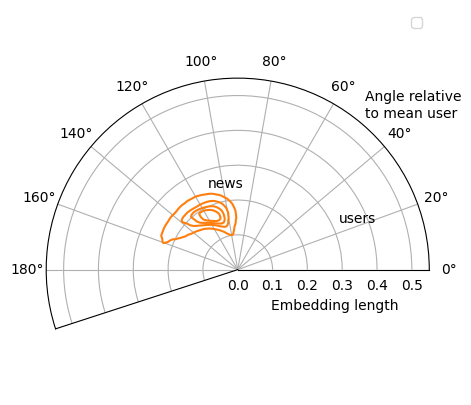

In [3]:
#N=1 without disentanglement

process_embeddings_geometry(
    N=1,
    user_path='/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_bce_N1/user_representations.pkl',
    candidate_path=candidate_path
)

Processing Geometry for N=5


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


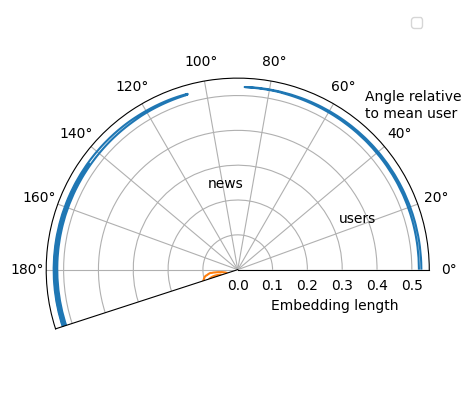

In [4]:
#N =5 without disentanglement
process_embeddings_geometry(
    N=5,
    user_path='/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N5_user_representations/user_representations.pkl',
    candidate_path=candidate_path
)

Processing Geometry for N=5


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


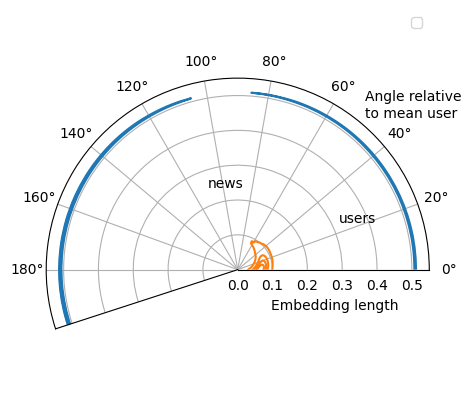

In [5]:
#N =5 with disentanglement
process_embeddings_geometry(
    N=5,
    user_path='/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N5_dis_cos_bce_lamda_s_0.9/user_representations.pkl',
    candidate_path=candidate_path
)

Processing Geometry for N=10


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


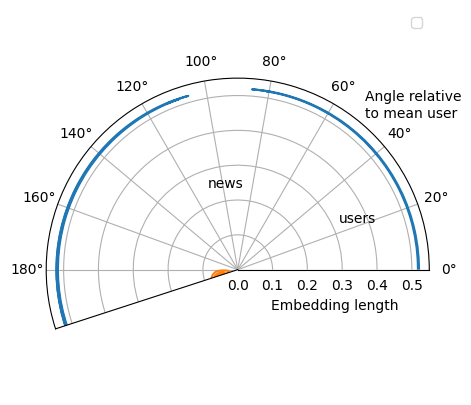

In [6]:
#N =10 without disentanglement
process_embeddings_geometry(
    N=10,
    user_path='/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N10_user_representations/user_representations.pkl',
    candidate_path=candidate_path
)

Processing Geometry for N=10


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


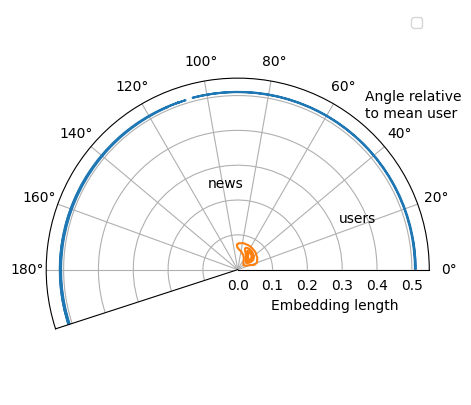

In [7]:
#N =10 with disentanglement
process_embeddings_geometry(
    N=10,
    user_path= '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N10_dis_cos_bce_lamda_s_0.9_user_representations/user_representations.pkl',
    candidate_path=candidate_path
)

Processing Geometry for N=25


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


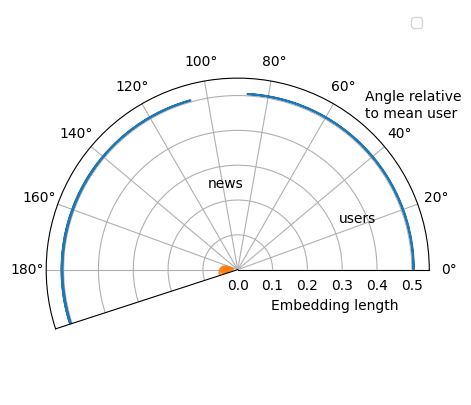

In [8]:
#N = 25 without disentanglement
process_embeddings_geometry(
    N=25,
    user_path='/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N25_user_representations/user_representations.pkl',
    candidate_path=candidate_path
)


Processing Geometry for N=25


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


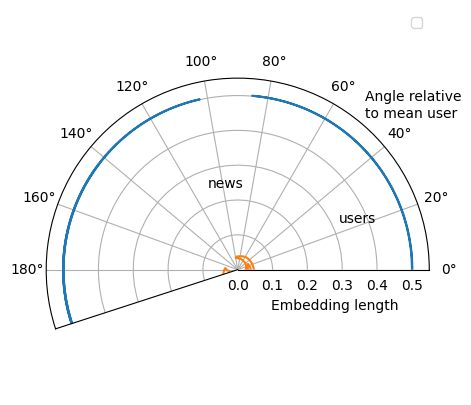

In [9]:
#N = 25 with disentanglement
process_embeddings_geometry(
    N=25,
    user_path= '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N25_dis_cos_bce_lamda_s_0.9/user_representations.pkl',
    candidate_path=candidate_path
)

Processing Geometry for N=50


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


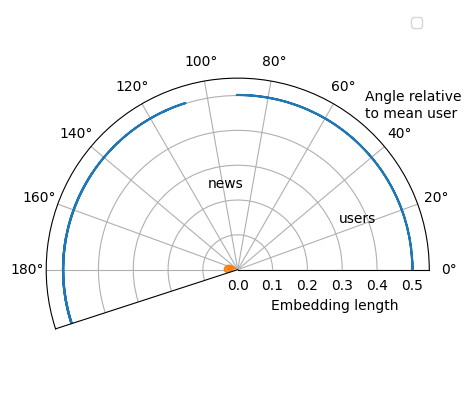

In [10]:
#N = 50 without disentanglement
process_embeddings_geometry(
    N=50,
    user_path='/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N50_user_representations/user_representations.pkl',
    candidate_path=candidate_path
)

Processing Geometry for N=50


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


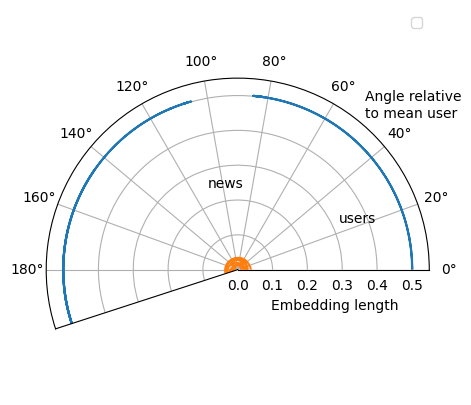

In [11]:
#N = 50 with disentanglement
process_embeddings_geometry(
    N=50,
    user_path='/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N50_dis_cos_bce_lamda_s_0.90/user_representations.pkl',
    candidate_path=candidate_path
)